# Used Car Listings: Features and Price Prediction

This notebook answers the 16 finalized questions using the actual source schemas. It uses the provided `train.csv` for training/cross-validation and the provided labeled `test.csv` as the external holdout. All monetary metrics are derived from the files during execution.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import ProjectConfig, run_analysis

TRAIN_PATH = Path(r"D:\Used Car Listings Features and Price Prediction\train.csv")
TEST_PATH = Path(r"D:\Used Car Listings Features and Price Prediction\test.csv")
config = ProjectConfig(project_root=PROJECT_ROOT, train_path=TRAIN_PATH, test_path=TEST_PATH)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Q1. Dataset Understanding and Data Structures

Load the data and inspect shape, columns, types, sample records, descriptive statistics, unique values, and memory usage. A `DataFrame` is the full table; selecting one column produces a `Series`; `list(df.columns)` is a Python list; summary mappings are dictionaries; and model matrices/predictions are NumPy arrays.

The shape formula is explicit: `rows = df.shape[0]`, `columns = df.shape[1]`, and `total_cells = rows * columns`.

In [2]:
train_raw = pd.read_csv(TRAIN_PATH, low_memory=False)
test_raw = pd.read_csv(TEST_PATH, low_memory=False)

for name, df in {"train": train_raw, "test": test_raw}.items():
    rows = df.shape[0]
    columns = df.shape[1]
    total_cells = rows * columns
    print(f"{name}: rows={rows:,}, columns={columns:,}, total cells={total_cells:,}")
    print(f"memory={df.memory_usage(deep=True).sum():,} bytes")

display(train_raw.head(), train_raw.tail())
display(train_raw.dtypes.rename("dtype").to_frame())
display(train_raw.describe(include="all").T)
display(train_raw.nunique(dropna=False).rename("unique_including_missing").to_frame())

train: rows=19,109, columns=36, total cells=687,924
memory=7,712,586 bytes
test: rows=4,778, columns=36, total cells=172,008
memory=1,928,694 bytes


,brand,model,year,mileage,engine,engine_size,transmission,automatic_transmission,fuel_type,drivetrain,min_mpg,max_mpg,damaged,first_owner,personal_using,turbo,alloy_wheels,adaptive_cruise_control,navigation_system,power_liftgate,backup_camera,keyless_start,remote_start,sunroof/moonroof,automatic_emergency_braking,stability_control,leather_seats,memory_seat,third_row_seating,apple_car_play/android_auto,bluetooth,usb_port,heated_seats,interior_color,exterior_color,price
0,Mazda,CX-9 Touring,"2,022.0000","6,580.0000",2.5L I4 16V GDI DOHC Turbo,2.5000,6-Speed Automatic,1.0000,Gasoline,Four-wheel Drive,NaN,NaN,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,Black,Snowflake White Pearl,36789
1,Alfa,Romeo Stelvio 4DR SUV AWD,"2,018.0000","62,717.0000",Twin Turbo Premium Unleaded V-6 2.9 L/176,2.9000,Automatic,1.0000,Gasoline,Four-wheel Drive,NaN,NaN,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,Black,Rosso Competizione Tri-Coat,39993
2,Chevrolet,Silverado 1500 Limited LT,"2,022.0000","15,463.0000",5.3L V8 16V GDI OHV,5.3000,Automatic,1.0000,Gasoline,Four-wheel Drive,NaN,NaN,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,Jet Black,Silver Ice Metallic,46986
3,Land,Rover Range Rover P400 SE,"2,022.0000","1,281.0000",3.0L I6 24V GDI DOHC Turbo,3.0000,Automatic,1.0000,Gasoline,Four-wheel Drive,NaN,NaN,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,Ebony,Fuji White,141999
4,Mitsubishi,Outlander Sport 2.0 SE,"2,021.0000","36,727.0000",2.0L I4 16V MPFI DOHC,2.0000,Automatic CVT,1.0000,Gasoline,Front-wheel Drive,NaN,NaN,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,Black,White,21595


,brand,model,year,mileage,engine,engine_size,transmission,automatic_transmission,fuel_type,drivetrain,min_mpg,max_mpg,damaged,first_owner,personal_using,turbo,alloy_wheels,adaptive_cruise_control,navigation_system,power_liftgate,backup_camera,keyless_start,remote_start,sunroof/moonroof,automatic_emergency_braking,stability_control,leather_seats,memory_seat,third_row_seating,apple_car_play/android_auto,bluetooth,usb_port,heated_seats,interior_color,exterior_color,price
19104,Lexus,RC 350 Base,"2,017.0000","77,886.0000",3.5L V6 24V PDI DOHC,3.5000,8-Speed Automatic,1.0000,Gasoline,Rear-wheel Drive,16.0000,25.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,Black,Obsidian Black,30023
19105,Chevrolet,Camaro 2SS,"2,020.0000","30,921.0000",6.2L V8 16V GDI OHV,6.2000,10-Speed Automatic,1.0000,Gasoline,Rear-wheel Drive,16.0000,24.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,Jet Black,Black,42500
19106,Hyundai,Palisade Calligraphy,"2,021.0000","25,490.0000",3.8L V6 24V GDI DOHC,3.8000,8-Speed Automatic,1.0000,Gasoline,Four-wheel Drive,NaN,NaN,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,Black,Becketts Black,43999
19107,Honda,Accord Sport,"2,019.0000","30,840.0000",1.5L I4 16V GDI DOHC Turbo,1.5000,Automatic CVT,1.0000,Gasoline,Front-wheel Drive,29.0000,35.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,Gray,White,26998
19108,MINI,Countryman Cooper S ALL4,"2,016.0000","110,107.0000",1.6L I4 16V GDI DOHC Turbo,1.6000,6-Speed Automatic,1.0000,Gasoline,Four-wheel Drive,NaN,NaN,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,Carbon Black,Absolute Black Metallic,15382


,dtype
brand,str
model,str
year,float64
mileage,float64
engine,str
engine_size,float64
transmission,str
automatic_transmission,float64
fuel_type,str
drivetrain,str


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand,19107,25,Audi,855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,19107,3498,Romeo Giulia Ti,169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,"19,107.0000",NaN,NaN,NaN,"2,017.7731",4.9964,"1,962.0000","2,016.0000","2,019.0000","2,021.0000","2,024.0000"
mileage,"19,107.0000",NaN,NaN,NaN,"47,947.0874","38,285.0612",0.0000,"19,307.0000","39,141.0000","68,431.5000","383,614.0000"
engine,19062,1163,2.0L I4 16V GDI DOHC Turbo,2324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine_size,"17,860.0000",NaN,NaN,NaN,2.9732,5.4780,0.0000,2.0000,2.5000,3.5000,390.0000
transmission,19004,189,8-Speed Automatic,5403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
automatic_transmission,"19,107.0000",NaN,NaN,NaN,0.9171,0.2757,0.0000,1.0000,1.0000,1.0000,1.0000
fuel_type,19107,10,Gasoline,17207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drivetrain,19107,5,Four-wheel Drive,10824,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,unique_including_missing
brand,26
model,3499
year,60
mileage,17413
engine,1164
engine_size,63
transmission,190
automatic_transmission,3
fuel_type,11
drivetrain,6


### Execute the reusable workflow

The next cell performs all cleaning, EDA, tuning, model fitting, evaluation, plots, business tables, model serialization, and validation. Re-running it refreshes every generated result from the source CSVs.

In [3]:
results = run_analysis(config)
print('Completed. Best external-test RMSE model:', results['best_model'])

Completed. Best external-test RMSE model: Ridge Regression


## Q2. Data Quality and Cleaning

Review missing values, duplicates, malformed targets, impossible numerical values, and text normalization. Predictor imputation is intentionally deferred to training-only pipelines.

In [4]:
display(pd.read_csv(PROJECT_ROOT / "outputs/tables/missing_values_after_row_cleaning.csv"))
display(results["cleaning"])

,column,train_missing,test_missing
0,brand,0,0
1,model,0,0
2,year,0,0
3,mileage,0,0
4,engine,45,6
5,engine_size,1261,285
6,transmission,98,17
7,automatic_transmission,0,0
8,fuel_type,0,0
9,drivetrain,0,0


{'train': {'raw_rows': 19109,
  'duplicate_rows_removed': 0,
  'invalid_or_missing_target_rows_removed': 34,
  'clean_rows': 19075,
  'reference_year_for_vehicle_age': 2024,
  'invalid_values_set_to_missing': {'year': 0,
   'mileage': 0,
   'engine_size': 14,
   'min_mpg': 179,
   'max_mpg': 89},
  'remaining_missing_values': 12775,
  'note': 'Remaining predictor gaps are imputed inside leakage-safe pipelines fit only on training data.'},
 'test': {'raw_rows': 4778,
  'duplicate_rows_removed': 0,
  'invalid_or_missing_target_rows_removed': 10,
  'clean_rows': 4768,
  'reference_year_for_vehicle_age': 2024,
  'invalid_values_set_to_missing': {'year': 0,
   'mileage': 0,
   'engine_size': 1,
   'min_mpg': 48,
   'max_mpg': 22},
  'remaining_missing_values': 3210,
  'note': 'Remaining predictor gaps are imputed inside leakage-safe pipelines fit only on training data.'}}

## Q3. Feature Classification and Selection

Classify continuous, binary, categorical, ordinal, identifier, and target fields. `vehicle_age` and `avg_mpg` are engineered when their source columns exist. Redundant originals are retained for EDA but omitted from the model matrix.

In [5]:
display(results['feature_classification'])
display(results['model_groups'])

{'numerical_continuous': ['year',
  'mileage',
  'engine_size',
  'min_mpg',
  'max_mpg',
  'vehicle_age',
  'avg_mpg'],
 'binary_indicator': ['automatic_transmission',
  'damaged',
  'first_owner',
  'personal_using',
  'turbo',
  'alloy_wheels',
  'adaptive_cruise_control',
  'navigation_system',
  'power_liftgate',
  'backup_camera',
  'keyless_start',
  'remote_start',
  'sunroof/moonroof',
  'automatic_emergency_braking',
  'stability_control',
  'leather_seats',
  'memory_seat',
  'third_row_seating',
  'apple_car_play/android_auto',
  'bluetooth',
  'usb_port',
  'heated_seats'],
 'categorical_nominal': ['brand',
  'model',
  'engine',
  'transmission',
  'fuel_type',
  'drivetrain',
  'interior_color',
  'exterior_color'],
 'ordinal': ['year', 'vehicle_age'],
 'identifier': [],
 'target': ['price']}

{'continuous': ['mileage', 'engine_size', 'vehicle_age', 'avg_mpg'],
 'binary': ['automatic_transmission',
  'damaged',
  'first_owner',
  'personal_using',
  'turbo',
  'alloy_wheels',
  'adaptive_cruise_control',
  'navigation_system',
  'power_liftgate',
  'backup_camera',
  'keyless_start',
  'remote_start',
  'sunroof/moonroof',
  'automatic_emergency_braking',
  'stability_control',
  'leather_seats',
  'memory_seat',
  'third_row_seating',
  'apple_car_play/android_auto',
  'bluetooth',
  'usb_port',
  'heated_seats'],
 'categorical': ['brand',
  'model',
  'engine',
  'transmission',
  'fuel_type',
  'drivetrain',
  'interior_color',
  'exterior_color'],
 'dropped_redundant': ['year', 'min_mpg', 'max_mpg']}

## Q4. Price Distribution and Outlier Analysis

IQR fences identify unusual values without automatically deleting them. The log-price view tests whether `log1p(price)` reduces positive skew.

{'raw_price_skew': np.float64(18.29721898032099), 'log1p_price_skew': np.float64(-0.03565128861173812)}


,feature,q1,q3,iqr,lower_fence,upper_fence,outlier_count,outlier_pct
0,price,"20,797.0000","43,950.0000","23,153.0000","-13,932.5000","78,679.5000",1039,5.4469
1,mileage,"19,297.0000","68,334.5000","49,037.5000","-54,259.2500","141,890.7500",463,2.4273
2,year,"2,016.0000","2,021.0000",5.0000,"2,008.5000","2,028.5000",837,4.3879
3,vehicle_age,3.0000,8.0000,5.0000,-4.5000,15.5000,837,4.3879
4,engine_size,2.0000,3.5000,1.5000,-0.2500,5.7500,567,3.1829
5,min_mpg,17.0000,24.0000,7.0000,6.5000,34.5000,336,2.1141
6,max_mpg,24.0000,31.0000,7.0000,13.5000,41.5000,251,1.5704
7,avg_mpg,20.5000,27.5000,7.0000,10.0000,38.0000,249,1.5579


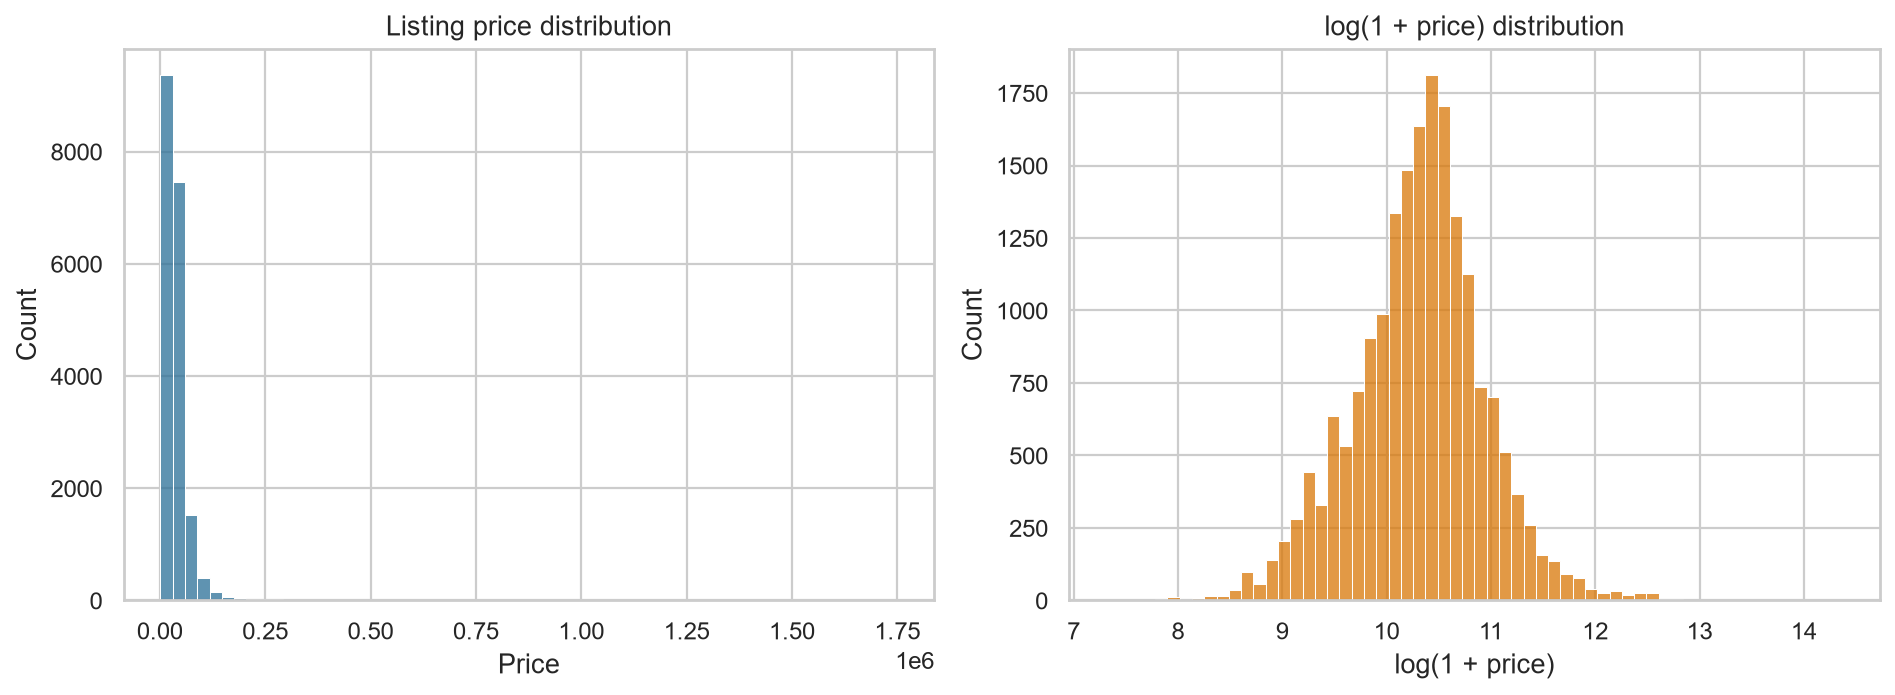

In [6]:
price_numeric = pd.to_numeric(train_raw["price"], errors="coerce").dropna()
print({"raw_price_skew": price_numeric.skew(), "log1p_price_skew": np.log1p(price_numeric).skew()})
display(results["outliers"])
display(Image(filename=str(PROJECT_ROOT / "outputs/figures/price_distribution_and_log.png")))

## Q5. Numerical Features vs Price

Pearson correlation summarizes linear association; Spearman correlation summarizes monotonic association. Correlation does not prove causation.

,feature,pearson_with_price,spearman_with_price,abs_pearson
0,mileage,-0.3830,-0.6691,0.3830
1,navigation_system,0.2843,0.4705,0.2843
2,year,0.2406,0.6430,0.2406
3,vehicle_age,-0.2406,-0.6430,0.2406
4,memory_seat,0.2113,0.4290,0.2113
5,avg_mpg,-0.2027,-0.3441,0.2027
6,max_mpg,-0.2015,-0.3317,0.2015
7,min_mpg,-0.1963,-0.3452,0.1963
8,apple_car_play/android_auto,0.1684,0.3252,0.1684
9,leather_seats,0.1575,0.3018,0.1575


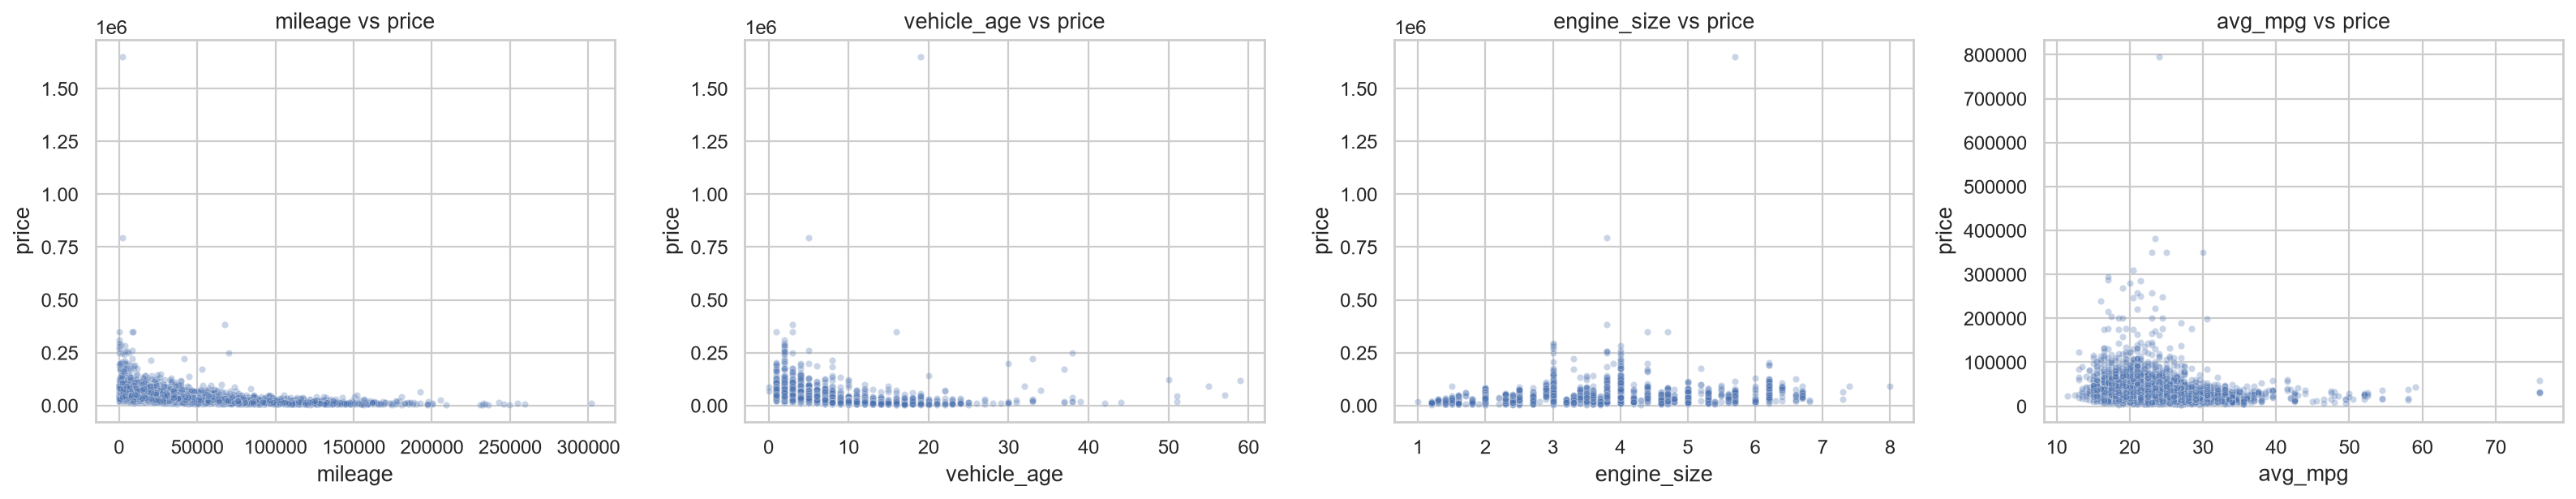

In [7]:
display(results["correlations"])
display(Image(filename=str(PROJECT_ROOT / "outputs/figures/numeric_features_vs_price.png")))

## Q6. Categorical Features vs Price

Compare mean and median price across both text categories and binary vehicle characteristics. This includes brand/model/fuel/transmission/drivetrain as well as indicators such as damage history, ownership, turbo, safety, and convenience features when available.


In [ ]:
cat_summary = results["categorical_summary"]
priority = ["brand", "model", "fuel_type", "transmission", "drivetrain", "damaged", "first_owner", "turbo"]
for feature in [c for c in priority if c in cat_summary["feature"].unique()]:
    display(Markdown(f"### {feature}"))
    display(cat_summary[cat_summary["feature"] == feature].sort_values("median_price", ascending=False).head(15))


## Q7. Encoding, Scaling, and Data Leakage Prevention

Continuous values use training-fold median imputation and standardization. Binary flags use training-fold mode imputation. Text categories use training-fold mode imputation and one-hot encoding with rare-category grouping. Scaling puts continuous predictors on comparable units, which makes Ridge and Lasso penalties meaningful. All transformations sit inside the pipeline; the holdout test file never teaches the preprocessing or model.

In [9]:
display(results['model_groups'])

{'continuous': ['mileage', 'engine_size', 'vehicle_age', 'avg_mpg'],
 'binary': ['automatic_transmission',
  'damaged',
  'first_owner',
  'personal_using',
  'turbo',
  'alloy_wheels',
  'adaptive_cruise_control',
  'navigation_system',
  'power_liftgate',
  'backup_camera',
  'keyless_start',
  'remote_start',
  'sunroof/moonroof',
  'automatic_emergency_braking',
  'stability_control',
  'leather_seats',
  'memory_seat',
  'third_row_seating',
  'apple_car_play/android_auto',
  'bluetooth',
  'usb_port',
  'heated_seats'],
 'categorical': ['brand',
  'model',
  'engine',
  'transmission',
  'fuel_type',
  'drivetrain',
  'interior_color',
  'exterior_color'],
 'dropped_redundant': ['year', 'min_mpg', 'max_mpg']}

## Q8. Baseline Multiple Linear Regression

MAE is average absolute dollar error. MSE squares errors and heavily weights large misses. RMSE is the square root of MSE and returns to price units. R² is the share of holdout variance explained relative to predicting the mean.

In [10]:
display(results['comparison'].query("Model == 'Linear Regression'"))

,Model,MAE,MSE,RMSE,R2,CV_RMSE_Mean,CV_RMSE_Std,Train_R2,Test_R2,Best_Alpha,Active_Features,Zero_Coefficients,Fit_Seconds,CV_Fold_RMSE,Generalization_Gap_R2,Overfit_Assessment
0,Linear Regression,"5,898.1892","194,393,736.7385","13,942.5154",0.7322,"25,812.3611","2,370.6736",0.4927,0.7322,N/A,630,0,1.0928,"26842.16, 27493.99, 23100.94",-0.2396,test set easier or sampling shift


## Q9. Linear Regression Interpretation and Diagnostics

Coefficients are on the standardized/encoded feature space and log-price target. Positive values raise predicted log-price; negative values lower it, holding other encoded inputs fixed. Residual skew and fitted-vs-absolute-residual correlation assess residual behavior and heteroscedasticity. Multicollinearity is measured explicitly with VIF-style diagnostics and a numeric condition number rather than only discussed conceptually.


In [ ]:
linear_coef = pd.read_csv(PROJECT_ROOT / "outputs/tables/linear_regression_coefficients.csv")
display(linear_coef.head(15))
display(linear_coef.sort_values("coefficient_log_price").head(15))
display(results["residual_diagnostics"])
display(results["multicollinearity_summary"])
display(results["multicollinearity_vif"].head(20))
display(Image(filename=str(PROJECT_ROOT / "outputs/figures/linear_regression_residuals.png")))


## Q10. Ridge Regression and Alpha Tuning

GridSearchCV uses the same seeded folds to select alpha. In addition to CV error, the project records the Ridge coefficient path across candidate alpha values, showing how stronger L2 regularization changes coefficient magnitude and model complexity.


In [ ]:
display(results["ridge_search"])
display(results["ridge_coefficient_path"])
display(results["comparison"].query("Model == 'Ridge Regression'"))


## Q11. Lasso Regression and Feature Selection

Lasso uses L1 regularization. Its exact zero coefficients remove encoded features from the fitted equation, making active/zero counts a direct feature-selection summary.

In [13]:
display(results["lasso_search"])
display(results["comparison"].query("Model == 'Lasso Regression'"))
lasso_coef = pd.read_csv(PROJECT_ROOT / "outputs/tables/lasso_regression_coefficients.csv")
display(lasso_coef[lasso_coef["is_zero"]].head(20))

,alpha,mean_train_neg_rmse_log,mean_cv_neg_rmse_log,cv_std_log,rank
0,0.0001,-0.2439,-0.2518,0.0049,1
1,0.0010,-0.2720,-0.2766,0.0035,2
2,0.0100,-0.3418,-0.3442,0.0043,3
3,0.1000,-0.4548,-0.4549,0.0064,4


,Model,MAE,MSE,RMSE,R2,CV_RMSE_Mean,CV_RMSE_Std,Train_R2,Test_R2,Best_Alpha,Active_Features,Zero_Coefficients,Fit_Seconds,CV_Fold_RMSE,Generalization_Gap_R2,Overfit_Assessment
2,Lasso Regression,"5,987.1617","198,892,886.2575","14,102.9389",0.7260,"25,942.3213","2,387.0993",0.4853,0.7260,0.0001,357,273,0.7624,"26983.45, 27632.02, 23211.49",-0.2408,test set easier or sampling shift


,feature,coefficient_log_price,absolute_coefficient,is_zero
357,cat__exterior_color_orange,-0.0000,0.0000,True
358,cat__exterior_color_silver ice metallic,-0.0000,0.0000,True
359,cat__exterior_color_radiant silver metallic,0.0000,0.0000,True
360,cat__exterior_color_yulong white,0.0000,0.0000,True
361,cat__exterior_color_vesuvio gray metallic,0.0000,0.0000,True
362,cat__exterior_color_velvet red pearlcoat,-0.0000,0.0000,True
363,cat__exterior_color_ultimate black,-0.0000,0.0000,True
364,cat__exterior_color_tourmaline blue metallic,0.0000,0.0000,True
365,cat__exterior_color_thunder gray metallic,0.0000,0.0000,True
366,cat__exterior_color_tan,0.0000,0.0000,True


## Q12. Cross-Validation of All Three Models

All models use the same external holdout and the same shuffled, seeded folds. `CV_RMSE_Mean` and `CV_RMSE_Std` are calculated in original price units after reversing the log transform.

In [14]:
display(results['comparison'][['Model','CV_RMSE_Mean','CV_RMSE_Std','CV_Fold_RMSE']])

,Model,CV_RMSE_Mean,CV_RMSE_Std,CV_Fold_RMSE
0,Linear Regression,"25,812.3611","2,370.6736","26842.16, 27493.99, 23100.94"
1,Ridge Regression,"25,812.8104","2,370.2379","26845.86, 27491.20, 23101.37"
2,Lasso Regression,"25,942.3213","2,387.0993","26983.45, 27632.02, 23211.49"


## Q13. Comprehensive Linear vs Ridge vs Lasso Comparison

The table includes MAE, MSE, RMSE, R², CV mean/std, train/test R², best alpha, active features, zero coefficients, fit time, and a train-test generalization assessment.

In [15]:
display(results['comparison'].sort_values('RMSE'))

,Model,MAE,MSE,RMSE,R2,CV_RMSE_Mean,CV_RMSE_Std,Train_R2,Test_R2,Best_Alpha,Active_Features,Zero_Coefficients,Fit_Seconds,CV_Fold_RMSE,Generalization_Gap_R2,Overfit_Assessment
1,Ridge Regression,"5,903.9197","194,383,461.4690","13,942.1469",0.7322,"25,812.8104","2,370.2379",0.4927,0.7322,0.1000,630,0,0.7474,"26845.86, 27491.20, 23101.37",-0.2395,test set easier or sampling shift
0,Linear Regression,"5,898.1892","194,393,736.7385","13,942.5154",0.7322,"25,812.3611","2,370.6736",0.4927,0.7322,N/A,630,0,1.0928,"26842.16, 27493.99, 23100.94",-0.2396,test set easier or sampling shift
2,Lasso Regression,"5,987.1617","198,892,886.2575","14,102.9389",0.7260,"25,942.3213","2,387.0993",0.4853,0.7260,0.0001,357,273,0.7624,"26983.45, 27632.02, 23211.49",-0.2408,test set easier or sampling shift


## Q14. Business Analysis — Vehicle Valuation

The strongest numerical relationships and model coefficients provide a consistent valuation starting point. A dealership can combine these signals with acquisition cost, reconditioning cost, local comparables, and desired margin when evaluating purchases, trade-ins, and listing prices.

In [16]:
display(results["correlations"].head(12))
best_key = results["best_model"].lower().replace(" ", "_")
best_coef = pd.read_csv(PROJECT_ROOT / f"outputs/tables/{best_key}_coefficients.csv")
display(best_coef.head(20))

,feature,pearson_with_price,spearman_with_price,abs_pearson
0,mileage,-0.3830,-0.6691,0.3830
1,navigation_system,0.2843,0.4705,0.2843
2,year,0.2406,0.6430,0.2406
3,vehicle_age,-0.2406,-0.6430,0.2406
4,memory_seat,0.2113,0.4290,0.2113
5,avg_mpg,-0.2027,-0.3441,0.2027
6,max_mpg,-0.2015,-0.3317,0.2015
7,min_mpg,-0.1963,-0.3452,0.1963
8,apple_car_play/android_auto,0.1684,0.3252,0.1684
9,leather_seats,0.1575,0.3018,0.1575


,feature,coefficient_log_price,absolute_coefficient,is_zero
0,cat__engine_4.0l h6 24v gdi dohc,0.8584,0.8584,False
1,cat__brand_suzuki,-0.8015,0.8015,False
2,cat__engine_3.8l h6 24v gdi dohc,0.7289,0.7289,False
3,cat__engine_6.2l v8 16v gdi ohv supercharged,0.7275,0.7275,False
4,cat__model_mc20 base,0.6655,0.6655,False
5,cat__engine_3.0l v6 24v pdi dohc twin turbo,0.6655,0.6655,False
6,cat__drivetrain_infrequent_sklearn,0.6470,0.6470,False
7,cat__brand_fiat,-0.5535,0.5535,False
8,cat__engine_6.4l v8 16v mpfi ohv,0.5410,0.5410,False
9,cat__engine_6.2l v8 16v gdi ohv,0.5148,0.5148,False


## Q15. Business Analysis — Depreciation and Inventory Strategy

Age bands summarize price decay. Retention slopes are calculated separately for every supported segment family—brand, model, fuel type, and drivetrain—when enough listings are available. Better apparent retention can still reflect trim mix, condition, or selection effects.


In [ ]:
display(results["depreciation"])
retention = results["retention"]
if "segment_feature" in retention.columns:
    for feature in retention["segment_feature"].unique():
        display(Markdown(f"### Retention by {feature}"))
        display(retention[retention["segment_feature"] == feature].head(20))
else:
    display(retention)


## Q16. Business Analysis — Pricing Strategy and Opportunities

`actual_minus_predicted` is positive when the listing is above the model benchmark. `predicted_minus_actual` is positive when it appears below the benchmark. A ±20% rule creates review queues. These are not automatic transactions: omitted trim, history, condition, geography, seller urgency, taxes, and market changes can explain a large difference.

In [18]:
pricing = results["pricing"]
display(pricing[pricing["pricing_flag"] == "potentially_underpriced"].head(20))
display(pricing[pricing["pricing_flag"] == "potentially_overpriced"].sort_values("actual_minus_predicted", ascending=False).head(20))
display(pricing["pricing_flag"].value_counts().rename_axis("flag").to_frame("listings"))

,brand,model,year,mileage,engine,engine_size,transmission,automatic_transmission,fuel_type,drivetrain,min_mpg,max_mpg,damaged,first_owner,personal_using,turbo,alloy_wheels,adaptive_cruise_control,navigation_system,power_liftgate,backup_camera,keyless_start,remote_start,sunroof/moonroof,automatic_emergency_braking,stability_control,leather_seats,memory_seat,third_row_seating,apple_car_play/android_auto,bluetooth,usb_port,heated_seats,interior_color,exterior_color,price,vehicle_age,avg_mpg,predicted_price,actual_minus_predicted,predicted_minus_actual,difference_pct_of_predicted,pricing_flag
3076,maserati,mc20 base,"2,022.0000",747.0000,3.0l v6 24v pdi dohc twin turbo,3.0000,8-speed automatic with auto-shift,1.0000,gasoline,rear-wheel drive,16.0000,23.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,blue,grigio mistero,"252,990.0000",2.0000,19.5000,"320,371.3730","-67,381.3730","67,381.3730",-21.0323,potentially_underpriced
1420,porsche,718 cayman gts 4.0,"2,022.0000","6,547.0000",4.0l h6 24v gdi dohc,4.0000,NaN,0.0000,gasoline,rear-wheel drive,17.0000,23.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,black,gt silver metallic,"99,810.0000",2.0000,20.0000,"164,066.1894","-64,256.1894","64,256.1894",-39.1648,potentially_underpriced
2270,mercedes-benz,gle 580 awd 4matic,"2,022.0000","6,333.0000",4.0l v8 32v gdi dohc twin turbo,4.0000,9-speed automatic,1.0000,gasoline,four-wheel drive,21.0000,30.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,black,obsidian black metallic,"88,995.0000",2.0000,25.5000,"133,554.0962","-44,559.0962","44,559.0962",-33.3641,potentially_underpriced
1580,porsche,taycan base,"2,022.0000","7,380.0000",electric,NaN,2-speed automatic,1.0000,electric,rear-wheel drive,17.0000,24.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,black,mahogany metallic,"84,495.0000",2.0000,20.5000,"123,278.4275","-38,783.4275","38,783.4275",-31.4600,potentially_underpriced
564,porsche,panamera turbo,"2,018.0000","29,781.0000",4.0l v8 32v gdi dohc twin turbo,4.0000,8-speed automatic with auto-shift,1.0000,gasoline,four-wheel drive,16.0000,23.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,black,red,"85,995.0000",6.0000,19.5000,"124,775.5234","-38,780.5234","38,780.5234",-31.0802,potentially_underpriced
2418,porsche,panamera gts,"2,019.0000","41,652.0000",4.0l v8 32v gdi dohc twin turbo,4.0000,8-speed automatic with auto-shift,1.0000,gasoline,four-wheel drive,NaN,NaN,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.0000,1.0000,black,night blue metallic,"87,497.0000",5.0000,NaN,"122,132.6787","-34,635.6787","34,635.6787",-28.3591,potentially_underpriced
1917,toyota,mirai base,"2,021.0000","20,132.0000",NaN,NaN,continuously variable,0.0000,unknown,rear-wheel drive,NaN,71.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,black,gray,"28,900.0000",3.0000,71.0000,"60,071.4195","-31,171.4195","31,171.4195",-51.8906,potentially_underpriced
4622,chevrolet,silverado 1500 ltz,"2,022.0000","13,483.0000",6.2l v8 16v gdi ohv,6.2000,10-speed automatic,1.0000,gasoline,four-wheel drive,NaN,NaN,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,gideon,iridescent pearl tricoat,"55,488.0000",2.0000,NaN,"86,462.6284","-30,974.6284","30,974.6284",-35.8243,potentially_

,brand,model,year,mileage,engine,engine_size,transmission,automatic_transmission,fuel_type,drivetrain,min_mpg,max_mpg,damaged,first_owner,personal_using,turbo,alloy_wheels,adaptive_cruise_control,navigation_system,power_liftgate,backup_camera,keyless_start,remote_start,sunroof/moonroof,automatic_emergency_braking,stability_control,leather_seats,memory_seat,third_row_seating,apple_car_play/android_auto,bluetooth,usb_port,heated_seats,interior_color,exterior_color,price,vehicle_age,avg_mpg,predicted_price,actual_minus_predicted,predicted_minus_actual,difference_pct_of_predicted,pricing_flag
1859,mercedes-benz,amg gt c,"2,021.0000","2,050.0000","amg 4l v-8 gasoline direct injection, dohc, va...",NaN,automatic,1.0000,gasoline,rear-wheel drive,19.0000,27.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,black,designo graphite gray magno,"389,900.0000",3.0000,23.0000,"77,665.6760","312,234.3240","-312,234.3240",402.0236,potentially_overpriced
4526,bmw,xm,"2,023.0000",754.0000,4.4l v8,4.4000,automatic,1.0000,gasoline,four-wheel drive,NaN,NaN,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,black,bay blue,"249,895.0000",1.0000,NaN,"54,888.9574","195,006.0426","-195,006.0426",355.2737,potentially_overpriced
3134,maserati,mc20 mc20,"2,022.0000","1,220.0000","nettuno 3l v-6 port/direct injection, dohc, va...",NaN,"automatic, 8-spd dual-clutch",1.0000,gasoline,rear-wheel drive,14.0000,18.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,NaN,NaN,"256,900.0000",2.0000,16.0000,"69,820.8001","187,079.1999","-187,079.1999",267.9419,potentially_overpriced
2522,porsche,911 turbo s,"2,022.0000","3,043.0000","3.8l h-6 gasoline direct injection, dohc, vari...",3.8000,automatic,1.0000,gasoline,four-wheel drive,18.0000,23.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,bordeaux red/black,black,"279,888.0000",2.0000,20.5000,"93,462.7732","186,425.2268","-186,425.2268",199.4647,potentially_overpriced
2184,mercedes-benz,sls amg base,"2,011.0000","21,213.0000",6.2l v8 32v mpfi dohc,6.2000,7-speed automatic with auto-shift,1.0000,gasoline,rear-wheel drive,22.0000,31.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,classic red,iridium silver metallic,"216,990.0000",13.0000,26.5000,"35,346.0671","181,643.9329","-181,643.9329",513.9014,potentially_overpriced
2648,porsche,911 gt3 rs,"2,019.0000","13,042.0000","4l h-6 gasoline direct injection, dohc, varioc...",4.0000,automatic,1.0000,gasoline,rear-wheel drive,23.0000,32.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,black,white,"254,888.0000",5.0000,27.5000,"73,597.5522","181,290.4478","-181,290.4478",246.3267,potentially_overpriced
1414,mercedes-benz,sls amg base,"2,011.0000","13,422.0000",6.2l v8 32v mpfi dohc,6.2000,7-speed automatic with auto-shift,1.0000,gasoline,rear-wheel drive,17.0000,25.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,red,silver,"213,990.0000",13.0000,21.0000,"42,234.5952","171,755.4048","-171,755.4048",406.6699,potentially_overpriced
1822,porsche,911 turbo s,"2,023.0000","1,972.0000",3.8l h6 24v gdi dohc twin turbo,3.8000,8-speed automatic,1.0000,gasoline,four-wheel drive,15.0000,23.0000,0.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,slate gray,gentian blue metallic,"279,999.0000",

,listings
flag,
within_20_percent,3510
potentially_overpriced,693
potentially_underpriced,565


## Final files

The workflow saves detailed tables, figures, fitted pipelines, an analysis summary, run metadata, and a validation report under `outputs/`. See `README.md` for the run order and `docs/methodology.md` for availability and fallback rules.